In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


### Data Loading

In [2]:
df = pd.read_csv('twitter_training.csv')
df.head(15)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
5,2402,Borderlands,Positive,So I spent a few hours making something for fu...
6,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
7,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
8,2402,Borderlands,Positive,So I spent a few hours making something for fu...
9,2402,Borderlands,Positive,2010 So I spent a few hours making something f...


### Data Cleaning

In [3]:
print(df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [4]:
df.columns = ['ID', 'Entity', 'Sentiment', 'Content']

# Now let's verify it worked
print(df.head())

     ID       Entity Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                             Content  
0  I am coming to the borders and I will kill you...  
1  im getting on borderlands and i will kill you ...  
2  im coming on borderlands and i will murder you...  
3  im getting on borderlands 2 and i will murder ...  
4  im getting into borderlands and i can murder y...  


In [5]:
df.head()

,ID,Entity,Sentiment,Content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [6]:
# Check the exact counts for each sentiment label
sentiment_distribution = df['Sentiment'].value_counts()

# Check the percentage (proportion) to see the relative share
sentiment_percentage = df['Sentiment'].value_counts(normalize=True) * 100

# Combine them into a simple summary table
summary_df = pd.DataFrame({
    'Count': sentiment_distribution,
    'Percentage (%)': sentiment_percentage.round(2)
})

print("--- Sentiment Distribution Summary ---")
print(summary_df)

--- Sentiment Distribution Summary ---
            Count  Percentage (%)
Sentiment                        
Negative    22542           30.18
Positive    20831           27.89
Neutral     18318           24.53
Irrelevant  12990           17.39


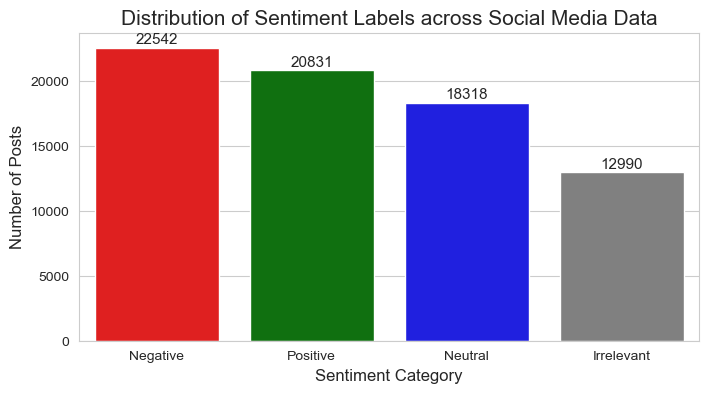

In [7]:
 # Set the figure size and style
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")

# Create the countplot
# We use a specific color palette to represent sentiments logically
colors = {"Positive": "green", "Negative": "red", "Neutral": "blue", "Irrelevant": "gray"}
sns.countplot(data=df, x='Sentiment', order=sentiment_distribution.index, palette=colors)

# Adding titles and labels for clarity
plt.title('Distribution of Sentiment Labels across Social Media Data', fontsize=15)
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

# Adding the count values on top of each bar for better readability
for i, count in enumerate(sentiment_distribution.values):
    plt.text(i, count + 50, str(count), ha='center', va='bottom', fontsize=11)

plt.show()

### Data Preprocessing

In [11]:
# Handling Missing Values

In [12]:
# Drop rows where the 'Content' column is empty (NaN)
df.dropna(subset=['Content'], inplace=True)

# Verify no more missing values exist
print(f"Missing values in Content: {df['Content'].isnull().sum()}")

Missing values in Content: 0


In [13]:
# The Cleaning Function

In [14]:
import re

def clean_social_media_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. Remove user @mentions and '#' from hashtags
    text = re.sub(r'\@\w+|\#', '', text)
    
    # 4. Remove special characters and numbers (keep only alphabets and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 5. Remove extra whitespace
    text = text.strip()
    
    return text

# Apply the function to create a new 'Clean_Content' column
df['Clean_Content'] = df['Content'].apply(clean_social_media_text)

# Let's see the difference!
print("--- Original vs Cleaned Text ---")
print(df[['Content', 'Clean_Content']].head())

--- Original vs Cleaned Text ---
                                             Content  \
0  I am coming to the borders and I will kill you...   
1  im getting on borderlands and i will kill you ...   
2  im coming on borderlands and i will murder you...   
3  im getting on borderlands 2 and i will murder ...   
4  im getting into borderlands and i can murder y...   

                                       Clean_Content  
0  i am coming to the borders and i will kill you...  
1  im getting on borderlands and i will kill you all  
2  im coming on borderlands and i will murder you...  
3  im getting on borderlands  and i will murder y...  
4  im getting into borderlands and i can murder y...  


In [15]:
# Library Used: VADER (Valence Aware Dictionary and sEntiment Reasoner)

In [16]:
# Scoring the Text
# We will create a function that takes our cleaned text and returns a "Compound Score."  
# Close to +1: Highly Positive  
# Close to -1: Highly Negative  
# Around 0: Neutral

In [17]:
!pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)


In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the analyzer
analyzer = SentimentIntensityAnalyzer()

In [19]:
def get_sentiment_score(text):
    # This returns a dictionary of scores (pos, neg, neu, compound)
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Apply the scoring to our cleaned content
df['Sentiment_Score'] = df['Clean_Content'].apply(get_sentiment_score)

# Preview the results
print(df[['Clean_Content', 'Sentiment_Score']].head(15))

                                        Clean_Content  Sentiment_Score
0   i am coming to the borders and i will kill you...          -0.6908
1   im getting on borderlands and i will kill you all          -0.6908
2   im coming on borderlands and i will murder you...          -0.6908
3   im getting on borderlands  and i will murder y...          -0.6908
4   im getting into borderlands and i can murder y...          -0.6908
5   so i spent a few hours making something for fu...           0.9477
6   so i spent a couple of hours doing something f...           0.9485
7   so i spent a few hours doing something for fun...           0.8720
8   so i spent a few hours making something for fu...           0.9477
9   so i spent a few hours making something for fu...           0.9477
10                                                was           0.0000
11  rockhard la varlope rare  powerful handsome ja...           0.7184
12  rockhard la varlope rare  powerful handsome ja...           0.7184
13  ro

#### Visualizing Specific Patterns

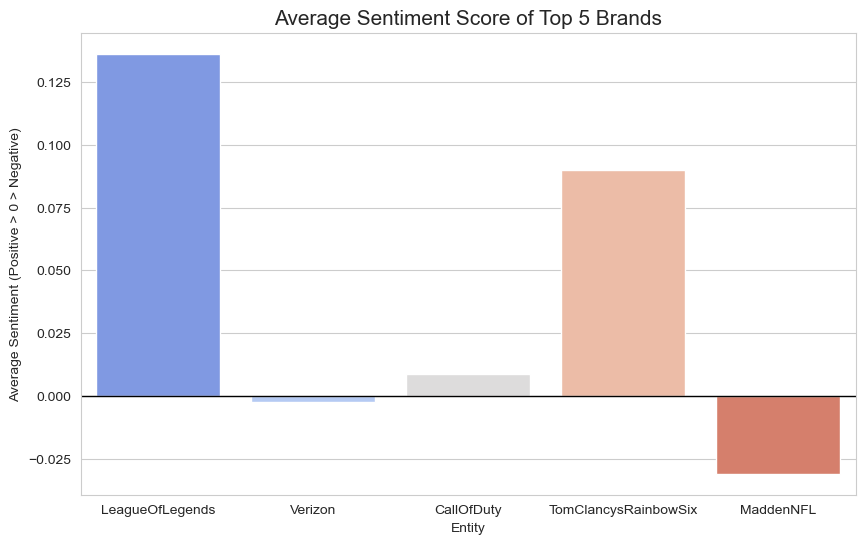

In [21]:
# 1. Pick the Top 5 most mentioned entities/brands in your data
top_entities = df['Entity'].value_counts().head(5).index
df_top = df[df['Entity'].isin(top_entities)]

# 2. Visualize the Average Sentiment Score for these brands
plt.figure(figsize=(10, 6))
sns.barplot(data=df_top, x='Entity', y='Sentiment_Score', palette='coolwarm', ci=None)

plt.title('Average Sentiment Score of Top 5 Brands', fontsize=15)
plt.axhline(0, color='black', lw=1) # Adds a "Neutral" line at zero
plt.ylabel('Average Sentiment (Positive > 0 > Negative)')
plt.show()

#### Advanced Pattern: Word Cloud
A word cloud is a "high-quality" way to see why a brand is getting a certain sentiment. Let's see the most common words in Negative posts.

In [24]:
!pip install wordcloud

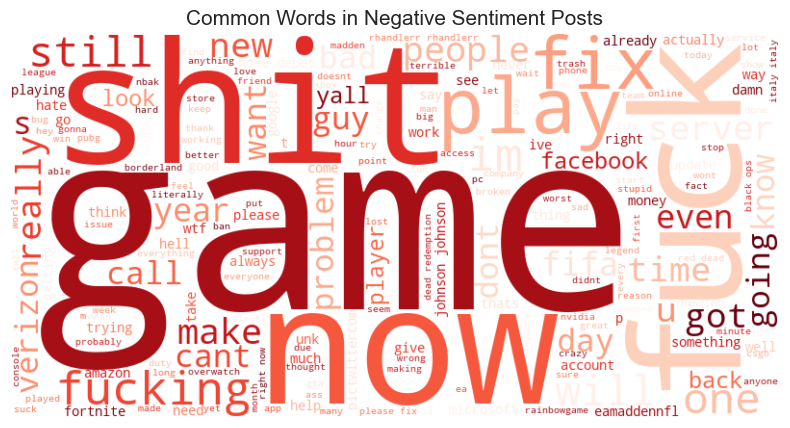

In [25]:
from wordcloud import WordCloud

# Combine all negative cleaned text into one big string
negative_text = " ".join(df[df['Sentiment'] == 'Negative']['Clean_Content'])

# Generate the Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# Display it
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Negative Sentiment Posts', fontsize=15)
plt.show()

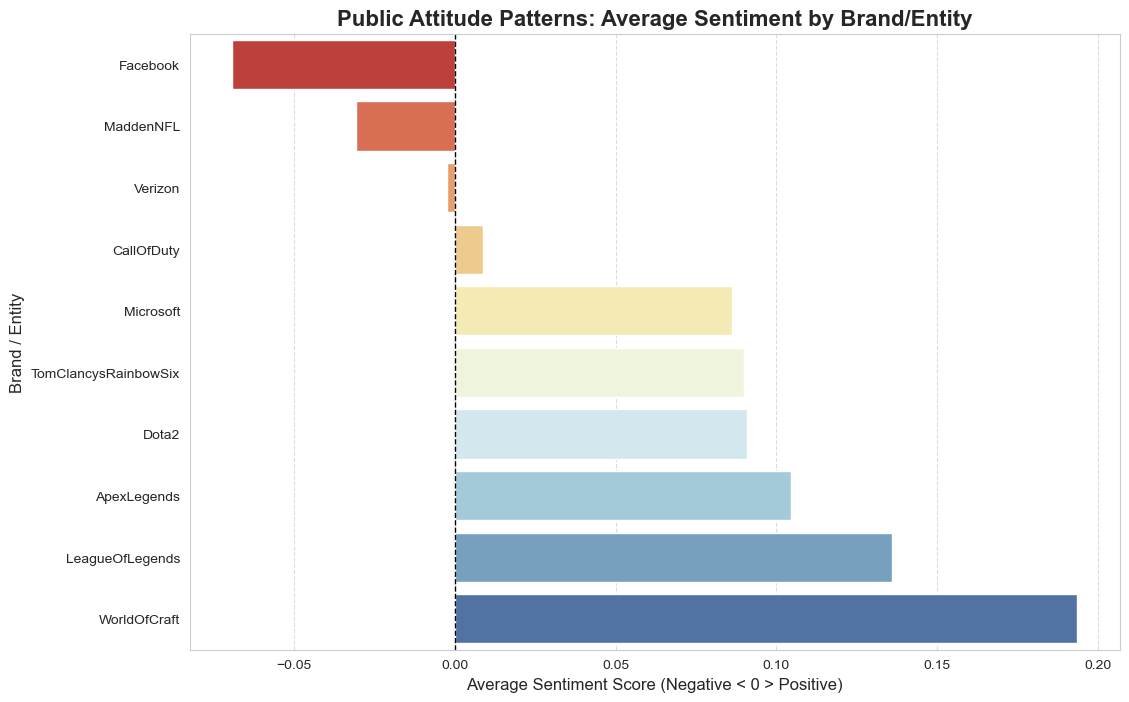

In [26]:
# 1. Identify the Top 10 most discussed entities (Brands/Games)
top_10_entities = df['Entity'].value_counts().head(10).index
df_top_10 = df[df['Entity'].isin(top_10_entities)]

# 2. Calculate the average sentiment for each
avg_sentiment = df_top_10.groupby('Entity')['Sentiment_Score'].mean().sort_values()

# 3. Create a High-Quality Horizontal Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(x=avg_sentiment.values, y=avg_sentiment.index, palette="RdYlBu")

# Formatting for "Quality Work"
plt.title('Public Attitude Patterns: Average Sentiment by Brand/Entity', fontsize=16, fontweight='bold')
plt.xlabel('Average Sentiment Score (Negative < 0 > Positive)', fontsize=12)
plt.ylabel('Brand / Entity', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1) # The "Neutral" threshold
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

##### Bars to the Right (Blue): These brands have a "Positive" public attitude. People are likely praising their features or services.

##### Bars to the Left (Red): These brands have "Negative" public opinion. This usually indicates technical issues, bad customer service, or unpopular updates.

##### Bars near Zero: These are "Neutral" or have a very split audience.